In [ ]:
# Run this cell if using a colab remote kernel and unable to resolve the import `from layoffs.data_loader import load_data`
# uncomment the first line if you have not run on this kernel before
# !git clone https://github.com/sidharthmirch/layoffs.git
!git -C /content/layoffs pull
import sys; sys.path.insert(0, '/content/layoffs')

Already up to date.


In [2]:
import pandas as pd
from layoffs.data_loader import load_data

train_df, test_df = load_data()

Using Colab cache for faster access to the 'global-company-layoffs-prediction-dataset' dataset.


In [ ]:
train_df.head()

,company,industry,country,funding_amount,employee_count,growth_rate,valuation,layoff_happened
0,Company_vrzD7Zhl,Real Estate,USA,917215428,53060,143.37,1.706021e+09,0
1,Company_3OJQGaHb,Automotive,Germany,3886088690,98556,177.24,1.869209e+10,0
2,Company_iChfXlEW,Real Estate,Germany,509868992,65992,58.26,3.079609e+09,1
3,Company_GBHyTQ2d,Logistics,UK,4180168950,38180,111.39,2.173688e+10,0
4,Company_cpOLkT6x,Tech,Japan,3031189942,56530,174.79,2.667447e+10,1


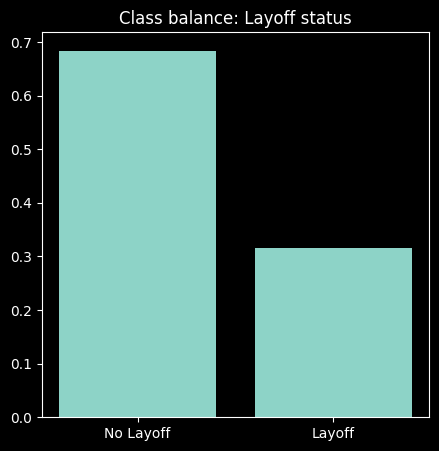

In [3]:
import matplotlib.pyplot as plt

counts = train_df["layoff_happened"].value_counts().sort_index()
proportions = counts / counts.sum()

plt.figure(figsize=(5, 5))
plt.bar(proportions.index, proportions.values)
plt.title("Class balance: Layoff status")
plt.xticks(proportions.index, ["No Layoff", "Layoff"])
plt.show()

In [4]:
# split into groups on `layoff_happened` 
laidoff_df = train_df[train_df["layoff_happened"] == 1]
desc_laid = laidoff_df.drop("layoff_happened", axis=1).describe().drop("count")

not_laidoff_df = train_df[train_df["layoff_happened"] == 0]
desc_not = not_laidoff_df.drop("layoff_happened", axis=1).describe().drop("count")

# combine into long form
laid = desc_laid.reset_index().rename(columns={"index": "stat"}).assign(group="Laid Off")
not_laid = desc_not.reset_index().rename(columns={"index": "stat"}).assign(group="No Layoffs")
combined = pd.concat([laid, not_laid], ignore_index=True)

features = ["funding_amount", "employee_count", "growth_rate", "valuation"]

tables = {}
for feat in features:
    # pivot so rows = group, cols = stat, values = feature
    tbl = combined.pivot(index="group", columns="stat", values=feat)
    # force order for summary stats
    stat_order = ["mean", "std", "min", "25%", "50%", "75%", "max"]
    cols = [c for c in stat_order if c in tbl.columns] + [c for c in tbl.columns if c not in stat_order]
    tbl = tbl[cols]

    # formatting 
    sty = tbl.style
    if feat in ["funding_amount", "valuation"]:
        sty = sty.format("${:,.0f}")
    elif feat == "employee_count":
        sty = sty.format("{:,.0f}")
    elif feat == "growth_rate":
        sty = sty.format("{:.2f}%")
    tables[feat] = sty

# display each styled table (in a notebook)
for feat, sty in tables.items():
    print(feat)
    display(sty)


funding_amount


stat,mean,std,min,25%,50%,75%,max
group,,,,,,,
Laid Off,"$2,456,185,540","$1,431,094,812","$1,298,162","$1,206,407,434","$2,449,680,129","$3,673,230,471","$4,999,076,071"
No Layoffs,"$2,480,315,159","$1,449,546,463","$2,866,983","$1,206,435,577","$2,482,935,737","$3,740,397,750","$4,999,505,410"


employee_count


stat,mean,std,min,25%,50%,75%,max
group,,,,,,,
Laid Off,"50,599","28,464",21,"25,548","50,790","75,204","99,996"
No Layoffs,"50,386","29,264",12,"25,398","50,513","76,424","99,987"


growth_rate


stat,mean,std,min,25%,50%,75%,max
group,,,,,,,
Laid Off,52.58%,75.17%,-49.89%,-15.99%,40.67%,117.24%,199.87%
No Layoffs,84.56%,68.58%,-50.00%,27.38%,85.12%,143.98%,200.00%


valuation


stat,mean,std,min,25%,50%,75%,max
group,,,,,,,
Laid Off,"$14,022,052,508","$10,651,917,091","$2,362,655","$5,633,695,135","$11,493,262,522","$20,444,087,737","$49,326,422,072"
No Layoffs,"$14,188,781,739","$10,890,826,135","$8,389,679","$5,677,617,696","$11,469,044,669","$20,731,881,277","$49,364,437,906"


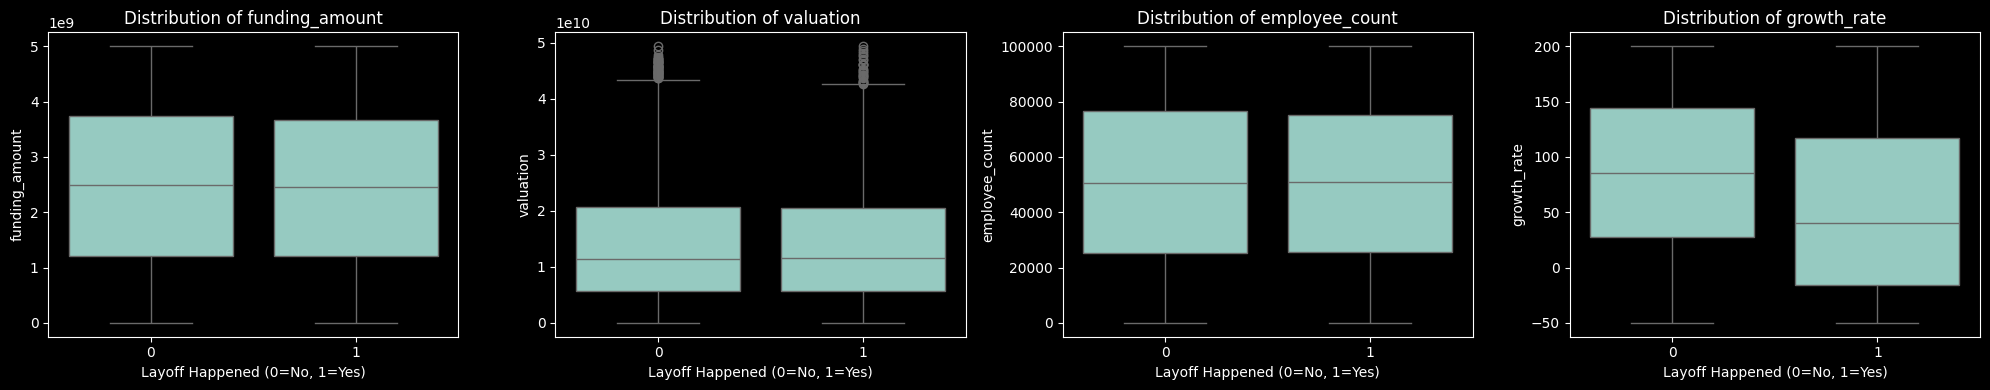

In [5]:
# code for boxplot distrib of each feature. KDE plots below offer much easier visualization to interp
import seaborn as sns

features = ["funding_amount", "valuation", "employee_count", "growth_rate"]

fig, axes = plt.subplots(1,4, figsize=(20, 4))

for i, feature in enumerate(features):

    sns.boxplot(data=train_df, x="layoff_happened", y=feature, ax=axes[i])
    
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel("Layoff Happened (0=No, 1=Yes)")
    
plt.tight_layout()
plt.show()

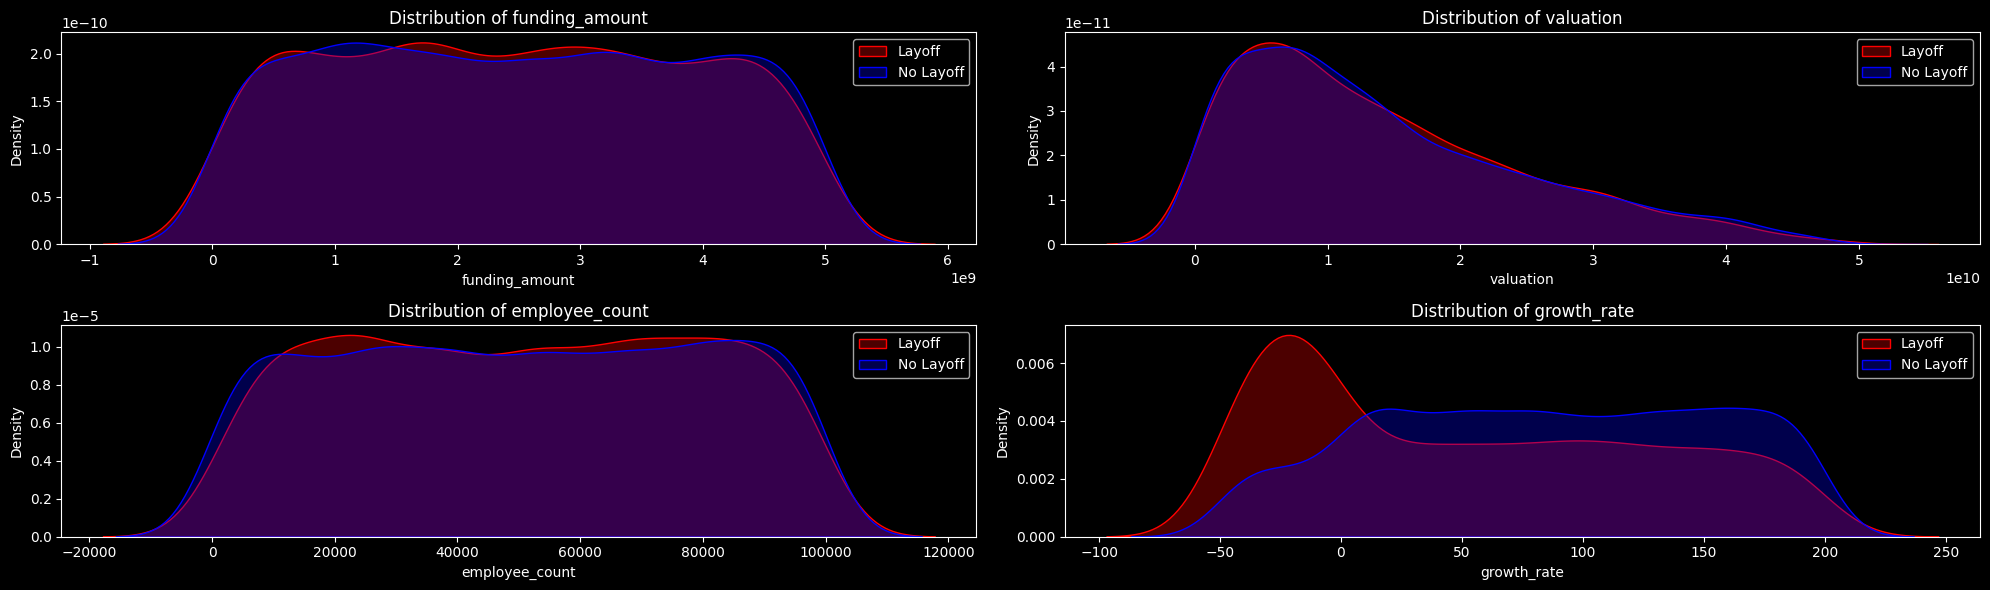

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(20, 6))

for i, col in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.kdeplot(data=laidoff_df, x=col, ax=ax, label="Layoff", color="red", fill=True, alpha=0.3)
    sns.kdeplot(data=not_laidoff_df, x=col, ax=ax, label="No Layoff", color="blue", fill=True, alpha=0.3)
    ax.set_title(f"Distribution of {col}")
    ax.legend()

plt.tight_layout()
plt.show()

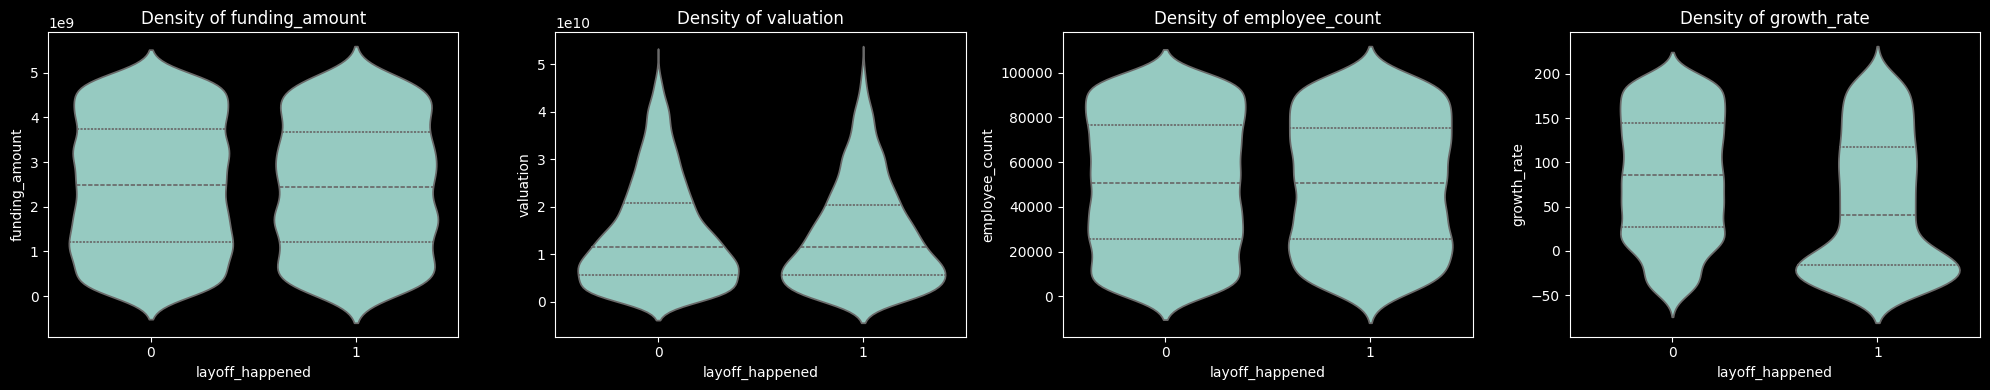

In [7]:
fig, axes = plt.subplots(1,4, figsize=(20,4))

for i, feature in enumerate(features):   

    sns.violinplot(data=train_df, x="layoff_happened", y=feature, ax=axes[i], inner="quartile")

    axes[i].set_title(f"Density of {feature}")

plt.tight_layout()
plt.show()

Inspecting our training data, we can see that between the firms that had layoffs and those that did not, only `growth_rate` appears to have a significantly different distribution. The other features behave identically between groups

$\quad\therefore\quad$ probably going to focus on growth rate as the main predictor of layoffs.

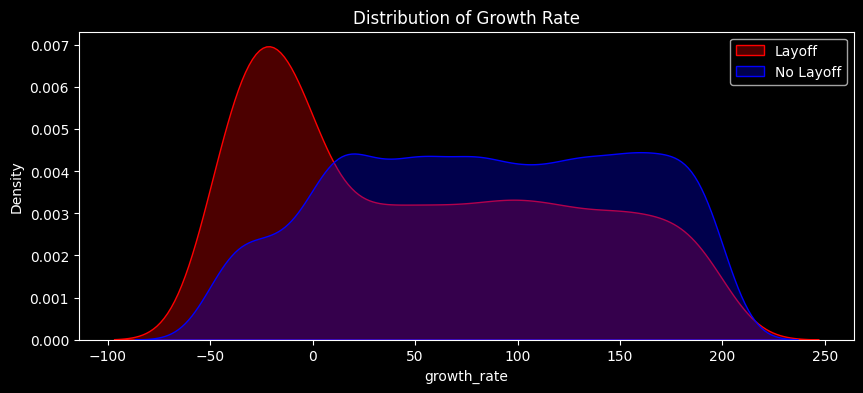

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

col = features[3]
sns.kdeplot(data=laidoff_df, x=col, ax=ax, label="Layoff", color="red", fill=True, alpha=0.3)
sns.kdeplot(data=not_laidoff_df, x=col, ax=ax, label="No Layoff", color="blue", fill=True, alpha=0.3)
ax.set_title("Distribution of Growth Rate")
ax.legend()

plt.show()